# Controlled Feature Ablations and Multi-Step Strategy
This experiment evaluates exactly five predeclared variants: Full Direct, Lags Only Direct, No-Calendar Direct, Minimal Direct, and Recursive Global. It asks which feature groups are associated with the Step 3 gain and whether recursive error propagation favors the direct strategy. All folds, series, metrics, sampling rules, and HGBR parameters are fixed. **No lockbox targets or prices are accessed.**

## Frozen comparison design
Direct training repeats the Step 3 weekly-origin rule. The recursive model uses every daily one-step origin from day 56 through `training_end-1`, declared before results, to provide dense temporal coverage while producing one label per origin. Direct ablations differ only in selected columns. Full Direct is preferred when it retains meaningful accuracy or recursive forecasting degrades; a simpler set is preferred only if its measured gap, folds, series regressions, and operational savings support equivalence.

In [1]:
from pathlib import Path
import sys,time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
from marketmind.forecasting.dataset import CATEGORICAL_COLUMNS,NUMERIC_COLUMNS,build_training_table,build_prediction_table,build_one_step_training_table,build_one_step_prediction_table,prepare_calendar,weekly_training_origins
from marketmind.forecasting.metrics import rmsse,mae
from marketmind.forecasting.strategies import recursive_forecast
DAYS=[f'd_{i}' for i in range(1,1914)]
FOLDS=[(1,1465,1466,1493),(2,1549,1550,1577),(3,1633,1634,1661),(4,1717,1718,1745),(5,1801,1802,1829),(6,1885,1886,1913)]
PARAMS=dict(loss='squared_error',learning_rate=.05,max_iter=120,max_leaf_nodes=31,max_depth=None,min_samples_leaf=100,l2_regularization=1.0,early_stopping=False,random_state=42)
ROLL=[f'rolling_{stat}_{w}' for w in (7,28,56) for stat in ('mean','std')]
LAGS=['lag_1','lag_7','lag_14','lag_28','lag_56']
VARIANTS={
 'full_direct':(CATEGORICAL_COLUMNS,NUMERIC_COLUMNS),
 'lags_only_direct':(CATEGORICAL_COLUMNS,[c for c in NUMERIC_COLUMNS if c not in ROLL]),
 'no_calendar_direct':(['store_id','dept_id','state_id'],['forecast_horizon',*LAGS,*ROLL,'day_index']),
 'minimal_direct':(['store_id','dept_id'],['forecast_horizon','lag_1','lag_7','lag_28']),
}
assert len(FOLDS)==6 and all(e-s+1==28 for _,_,s,e in FOLDS) and max(e for *_,e in FOLDS)==1913

## Data, features, and leakage assertions
Full Direct uses all Step 3 features. Lags Only removes six rolling summaries. No-Calendar retains lags, rolling summaries, identity, horizon, and sequential day index but removes weekday/day/month/year/events/SNAP. Minimal retains only lags 1/7/28, horizon, store, and department. Recursive uses the Full historical/calendar/identity set for `t+1`, without horizon. Fold-local encoders are fitted separately for every variant. Prices and target encoding are absent.

In [2]:
sales=pd.read_csv(ROOT/'data/raw/m5/sales_train_validation.csv',usecols=['dept_id','store_id','state_id',*DAYS])
calendar=prepare_calendar(pd.read_csv(ROOT/'data/raw/m5/calendar.csv'))
core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[DAYS].sum().reset_index()
values=core[DAYS].to_numpy(np.float32); series=core[['state_id','store_id','dept_id']]
assert len(core)==70 and series[['store_id','dept_id']].drop_duplicates().shape[0]==70
def fit_encoded(X,y,cats,nums):
 enc=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,encoded_missing_value=-1,dtype=np.float32)
 encoded=np.column_stack([enc.fit_transform(X[cats]),X[nums].to_numpy(np.float32)]) if cats else X[nums].to_numpy(np.float32)
 model=HistGradientBoostingRegressor(categorical_features=list(range(len(cats))),**PARAMS).fit(encoded,y)
 return enc,model
def transform(enc,X,cats,nums): return np.column_stack([enc.transform(X[cats]),X[nums].to_numpy(np.float32)]) if cats else X[nums].to_numpy(np.float32)
def record_metrics(rows,forecast,actual,train,fold,variant):
 for i,item in series.reset_index(drop=True).iterrows():
  rows.append({**item.to_dict(),'fold':fold,'variant':variant,'rmsse':rmsse(actual[i],forecast[i],train[i]),'mae':mae(actual[i],forecast[i]),'absolute_error':np.abs(actual[i]-forecast[i]).sum(),'signed_error':(forecast[i]-actual[i]).sum(),'actual_total':actual[i].sum()})

/var/folders/qr/5t89y2n92z12ddb73k2_ybdm0000gn/T/ipykernel_61988/2755252811.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[DAYS].sum().reset_index()


## Train and evaluate all five variants
For recursion, the callback receives observed history through issuance plus prior model predictions only. Its asserted width is `train_end + h - 1`; therefore validation actuals cannot enter. Each prediction is appended before the next horizon's lags and rolling values are rebuilt.

In [3]:
metric_rows=[]; horizon_rows=[]; compute=[]
for fold,train_end,val_start,val_end in FOLDS:
 train=values[:,:train_end]; actual=values[:,val_start-1:val_end]
 origins=weekly_training_origins(train_end); assert origins[-1]+28==train_end and np.all(origins+28<=train_end)
 start=time.perf_counter(); X_direct,y_direct=build_training_table(series,values,calendar,origins); direct_build=time.perf_counter()-start
 X_valid=build_prediction_table(series,train,calendar,train_end)
 for variant,(cats,nums) in VARIANTS.items():
  subset=cats+nums; memory=(X_direct[subset].memory_usage(deep=True).sum()+y_direct.nbytes)/1024**2
  start=time.perf_counter(); enc,model=fit_encoded(X_direct,y_direct,cats,nums); fit_seconds=time.perf_counter()-start
  start=time.perf_counter(); raw=model.predict(transform(enc,X_valid,cats,nums)).reshape(70,28); forecast_seconds=time.perf_counter()-start
  forecast=np.clip(raw,0,None); record_metrics(metric_rows,forecast,actual,train,fold,variant)
  for i,item in series.reset_index(drop=True).iterrows():
   for h in range(28): horizon_rows.append({'fold':fold,'variant':variant,'horizon':h+1,'actual':actual[i,h],'forecast':forecast[i,h],'error':forecast[i,h]-actual[i,h]})
  compute.append({'fold':fold,'variant':variant,'training_rows':len(X_direct),'memory_mb':memory,'build_seconds':direct_build,'fit_seconds':fit_seconds,'forecast_seconds':forecast_seconds,'negative_predictions':int((raw<0).sum())})
 one_origins=np.arange(56,train_end,dtype=np.int16); assert one_origins[-1]+1==train_end
 start=time.perf_counter(); X_one,y_one=build_one_step_training_table(series,values,calendar,one_origins); one_build=time.perf_counter()-start
 rcats=CATEGORICAL_COLUMNS; rnums=[c for c in NUMERIC_COLUMNS if c!='forecast_horizon']
 memory=(X_one.memory_usage(deep=True).sum()+y_one.nbytes)/1024**2
 start=time.perf_counter(); renc,rmodel=fit_encoded(X_one,y_one,rcats,rnums); fit_seconds=time.perf_counter()-start
 raw_negative=[0]
 def predict_next(history,h):
  assert history.shape[1]==train_end+h-1
  features=build_one_step_prediction_table(series,history,calendar,train_end+h-1)
  raw=rmodel.predict(transform(renc,features,rcats,rnums)); raw_negative[0]+=int((raw<0).sum())
  return np.clip(raw,0,None)
 start=time.perf_counter(); recursive=recursive_forecast(train,28,predict_next); forecast_seconds=time.perf_counter()-start
 record_metrics(metric_rows,recursive,actual,train,fold,'recursive_global')
 for i,item in series.reset_index(drop=True).iterrows():
  for h in range(28): horizon_rows.append({'fold':fold,'variant':'recursive_global','horizon':h+1,'actual':actual[i,h],'forecast':recursive[i,h],'error':recursive[i,h]-actual[i,h]})
 compute.append({'fold':fold,'variant':'recursive_global','training_rows':len(X_one),'memory_mb':memory,'build_seconds':one_build,'fit_seconds':fit_seconds,'forecast_seconds':forecast_seconds,'negative_predictions':raw_negative[0]})
 print(f'fold {fold} complete: direct rows {len(X_direct):,}; recursive rows {len(X_one):,}')
results=pd.DataFrame(metric_rows); horizons=pd.DataFrame(horizon_rows); compute=pd.DataFrame(compute)
compute

fold 1 complete: direct rows 388,080; recursive rows 98,630


fold 2 complete: direct rows 411,600; recursive rows 104,510


fold 3 complete: direct rows 435,120; recursive rows 110,390


fold 4 complete: direct rows 458,640; recursive rows 116,270


fold 5 complete: direct rows 482,160; recursive rows 122,150


fold 6 complete: direct rows 505,680; recursive rows 128,030


,fold,variant,training_rows,memory_mb,build_seconds,fit_seconds,forecast_seconds,negative_predictions
0,1,full_direct,388080,120.519506,2.128343,2.151866,0.006321,0
1,1,lags_only_direct,388080,111.637060,2.128343,1.697086,0.005359,0
2,1,no_calendar_direct,388080,78.726093,2.128343,1.457394,0.005175,0
3,1,minimal_direct,388080,47.267429,2.128343,1.141624,0.004731,0
4,1,recursive_global,98630,30.535566,1.168927,0.799205,0.128884,0
5,2,full_direct,411600,127.832558,2.278896,2.113407,0.006800,0
6,2,lags_only_direct,411600,118.411781,2.278896,1.714098,0.005843,0
7,2,no_calendar_direct,411600,83.497364,2.278896,1.509758,0.005638,0
8,2,minimal_direct,411600,50.132114,2.278896,1.163605,0.005998,0
9,2,recursive_global,104510,32.357571,1.233684,0.893155,0.126038,0


## Core and fold results
Differences are challenger minus Full Direct, so positive RMSSE differences indicate degradation. Improvements versus historical mean use the frozen 1.06690 reference.

In [4]:
overall=results.groupby('variant').agg(macro_rmsse=('rmsse','mean'),macro_mae=('mae','mean'),absolute_error=('absolute_error','sum'),actual_total=('actual_total','sum'),signed_error=('signed_error','sum')).reset_index()
overall['pooled_wape']=overall.absolute_error/overall.actual_total; overall['pooled_bias']=overall.signed_error/overall.actual_total
full=float(overall.loc[overall.variant=='full_direct','macro_rmsse'].iloc[0])
overall['rmsse_difference_vs_full']=overall.macro_rmsse-full; overall['relative_difference_vs_full_pct']=100*overall.rmsse_difference_vs_full/full
overall['improvement_vs_historical_mean']=1.06690-overall.macro_rmsse
display(overall.drop(columns=['absolute_error','actual_total','signed_error']).sort_values('macro_rmsse'))
fold_summary=results.groupby(['fold','variant']).agg(macro_rmsse=('rmsse','mean'),macro_mae=('mae','mean'),absolute_error=('absolute_error','sum'),actual_total=('actual_total','sum'),signed_error=('signed_error','sum')).reset_index()
fold_summary['pooled_wape']=fold_summary.absolute_error/fold_summary.actual_total; fold_summary['pooled_bias']=fold_summary.signed_error/fold_summary.actual_total
display(fold_summary.drop(columns=['absolute_error','actual_total','signed_error']))
display(fold_summary.groupby('variant').macro_rmsse.std().sort_values().rename('fold_rmsse_std').to_frame())

,variant,macro_rmsse,macro_mae,pooled_wape,pooled_bias,rmsse_difference_vs_full,relative_difference_vs_full_pct,improvement_vs_historical_mean
4,recursive_global,0.769570,57.881881,0.103823,-0.004802,-0.009590,-1.230763,0.297330
0,full_direct,0.779160,59.191994,0.106173,-0.011165,0.000000,0.000000,0.287740
1,lags_only_direct,0.836355,63.371252,0.113669,-0.027072,0.057195,7.340614,0.230545
3,no_calendar_direct,0.882995,72.896398,0.130754,-0.012139,0.103835,13.326566,0.183905
2,minimal_direct,0.975775,80.231662,0.143911,-0.046653,0.196615,25.234245,0.091125


,fold,variant,macro_rmsse,macro_mae,pooled_wape,pooled_bias
0,1,full_direct,0.865964,63.994646,0.120992,-0.028667
1,1,lags_only_direct,0.988568,76.062611,0.143808,-0.050857
2,1,minimal_direct,1.134841,93.600442,0.176966,-0.071941
3,1,no_calendar_direct,0.964740,78.630932,0.148664,-0.027395
4,1,recursive_global,0.867773,64.868908,0.122645,-0.009450
5,2,full_direct,0.681096,49.801777,0.094852,-0.009675
6,2,lags_only_direct,0.744505,53.206733,0.101337,-0.030599
7,2,minimal_direct,0.847584,66.275608,0.126228,-0.032913
8,2,no_calendar_direct,0.787058,61.918335,0.117929,-0.009011
9,2,recursive_global,0.694764,51.267743,0.097644,-0.004750


,fold_rmsse_std
variant,
recursive_global,0.092060
no_calendar_direct,0.092913
full_direct,0.096678
lags_only_direct,0.113215
minimal_direct,0.123536


## Series-level controlled comparison
Counts and median differences compare each challenger with Full Direct over each series' six-fold mean RMSSE. Negative difference means the challenger improves. Previously difficult series remain included and are displayed separately.

In [5]:
series_scores=results.groupby(['state_id','store_id','dept_id','variant']).rmsse.mean().unstack('variant')
comparisons=[]
for challenger in [v for v in overall.variant if v!='full_direct']:
 diff=series_scores[challenger]-series_scores.full_direct
 comparisons.append({'challenger':challenger,'improved':int((diff<0).sum()),'regressed':int((diff>0).sum()),'tied':int((diff==0).sum()),'median_rmsse_difference':diff.median(),'largest_improvement':diff.min(),'largest_regression':diff.max()})
display(pd.DataFrame(comparisons))
for challenger in [v for v in overall.variant if v!='full_direct']:
 diff=(series_scores[challenger]-series_scores.full_direct).sort_values()
 print('CHALLENGER',challenger); display(diff.head(3).rename('difference').to_frame()); display(diff.tail(3).rename('difference').to_frame())
display(series_scores.loc[[('CA','CA_4','HOBBIES_2'),('CA','CA_2','FOODS_2'),('TX','TX_1','HOBBIES_2')]])

,challenger,improved,regressed,tied,median_rmsse_difference,largest_improvement,largest_regression
0,lags_only_direct,16,54,0,0.041485,-0.122546,0.263981
1,minimal_direct,9,61,0,0.141018,-0.206159,1.230009
2,no_calendar_direct,10,60,0,0.088321,-0.083574,0.613421
3,recursive_global,44,26,0,-0.013430,-0.207669,0.133220


CHALLENGER lags_only_direct


,,,difference
state_id,store_id,dept_id,
CA,CA_3,FOODS_3,-0.122546
WI,WI_1,HOBBIES_2,-0.076899
CA,CA_3,HOUSEHOLD_1,-0.038362


difference
state_id store_id dept_id                
TX       TX_3     HOBBIES_2      0.248413
CA       CA_3     HOBBIES_2      0.262897
         CA_4     HOUSEHOLD_1    0.263981

CHALLENGER minimal_direct


...

difference
state_id store_id dept_id            
TX       TX_3     FOODS_2    0.361564
WI       WI_3     FOODS_2    0.396734
         WI_2     FOODS_2    0.613421

CHALLENGER recursive_global


,,,difference
state_id,store_id,dept_id,
WI,WI_2,FOODS_2,-0.207669
CA,CA_2,FOODS_2,-0.129260
TX,TX_2,HOBBIES_2,-0.122226


difference
state_id store_id dept_id                
CA       CA_3     FOODS_1        0.111901
         CA_4     HOBBIES_2      0.113190
WI       WI_1     HOUSEHOLD_2    0.133220

variant                      full_direct  lags_only_direct  minimal_direct  \
state_id store_id dept_id                                                    
CA       CA_4     HOBBIES_2     1.623835          1.675226        1.417677   
         CA_2     FOODS_2       1.487787          1.453111        1.820383   
TX       TX_1     HOBBIES_2     1.380340          1.425563        1.460261   

variant                      no_calendar_direct  recursive_global  
state_id store_id dept_id                                          
CA       CA_4     HOBBIES_2            1.633411          1.737025  
         CA_2     FOODS_2              1.703693          1.358527  
TX       TX_1     HOBBIES_2            1.373223          1.452410

## Direct versus recursive horizon behavior
Grouped horizon metrics pool the same 70 series and six folds. Bias is signed forecast-minus-actual divided by actual demand. Curves reveal association with horizon, not causation.

,variant,block,mae,wape,bias
0,full_direct,1-7,55.908726,0.099164,-0.015168
1,full_direct,8-14,60.194536,0.106244,-0.022902
2,full_direct,15-21,59.517972,0.107094,-0.006319
3,full_direct,22-28,61.146741,0.112422,0.000260
4,recursive_global,1-7,53.675296,0.095202,-0.011205
5,recursive_global,8-14,58.048850,0.102457,-0.012489
6,recursive_global,15-21,59.105264,0.106351,-0.006800
7,recursive_global,22-28,60.698115,0.111597,0.011883


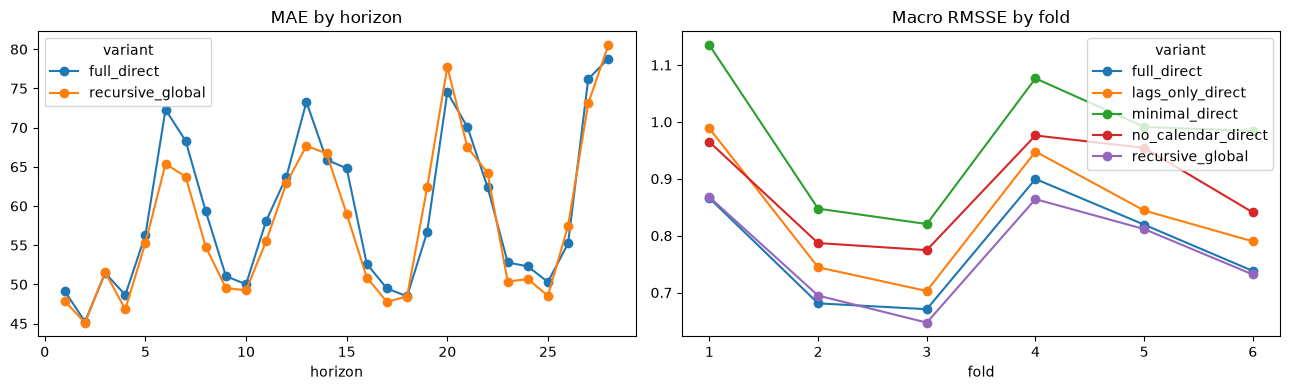

In [6]:
focus=horizons[horizons.variant.isin(['full_direct','recursive_global'])].copy(); focus['block']=pd.cut(focus.horizon,[0,7,14,21,28],labels=['1-7','8-14','15-21','22-28'])
blocks=focus.groupby(['variant','block'],observed=True).agg(mae=('error',lambda x:x.abs().mean()),absolute_error=('error',lambda x:x.abs().sum()),actual_total=('actual','sum'),signed_error=('error','sum')).reset_index()
blocks['wape']=blocks.absolute_error/blocks.actual_total; blocks['bias']=blocks.signed_error/blocks.actual_total
display(blocks.drop(columns=['absolute_error','actual_total','signed_error']))
curve=focus.groupby(['variant','horizon']).agg(mae=('error',lambda x:x.abs().mean()),signed_error=('error','sum'),actual_total=('actual','sum')).reset_index(); curve['bias']=curve.signed_error/curve.actual_total
fig,axes=plt.subplots(1,2,figsize=(13,4)); curve.pivot(index='horizon',columns='variant',values='mae').plot(marker='o',ax=axes[0],title='MAE by horizon'); fold_summary.pivot(index='fold',columns='variant',values='macro_rmsse').plot(marker='o',ax=axes[1],title='Macro RMSSE by fold'); plt.tight_layout(); plt.show()

## Computational comparison and decision
Build time is reported for the shared full direct table on every direct row; it should not be summed across direct variants as if rebuilt four times. Variant memory reflects selected columns plus target. Recursive forecast generation includes 28 sequential feature rebuilds. The evidence determines whether direct strategy and feature scope proceed, but HGBR parameters and final family remain unfrozen.

In [7]:
compute_summary=compute.groupby('variant').agg(training_rows=('training_rows','mean'),memory_mb=('memory_mb','mean'),build_seconds=('build_seconds','mean'),fit_seconds=('fit_seconds','mean'),forecast_seconds=('forecast_seconds','mean'),negative_predictions=('negative_predictions','sum')).sort_values('fit_seconds')
compute_summary

,training_rows,memory_mb,build_seconds,fit_seconds,forecast_seconds,negative_predictions
variant,,,,,,
recursive_global,113330.0,35.088051,1.342946,0.865664,0.136722,0
minimal_direct,446880.0,54.429142,2.470331,1.173072,0.005515,0
no_calendar_direct,446880.0,90.654270,2.470331,1.656632,0.005070,0
lags_only_direct,446880.0,128.558498,2.470331,1.842968,0.006227,0
full_direct,446880.0,138.786769,2.470331,2.313154,0.006233,0
